In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc

# Load dataset
df = pd.read_csv('/kaggle/input/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv')



In [17]:
# Preprocess data
df = df.drop(columns=['customerID'])  # Remove customer ID column
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.fillna(df.select_dtypes(include=[np.number]).median(), inplace=True)  # Fill missing values only for numeric columns
df = pd.get_dummies(df, drop_first=True)  # Convert categorical variables to dummy variables

# Define features and target
X = df.drop(columns=['Churn_Yes'])  # Independent variables
y = df['Churn_Yes']  # Dependent variable (binary classification)

# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)




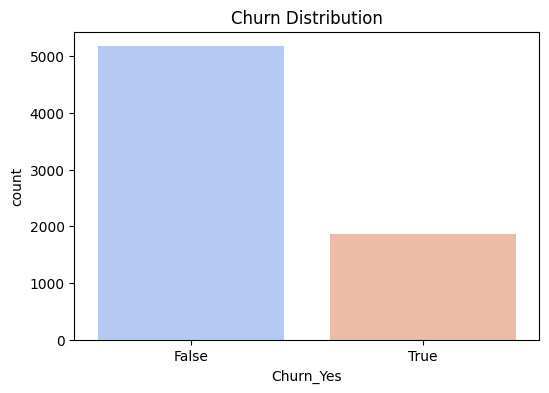

In [18]:
# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Visualization: Churn Distribution
plt.figure(figsize=(6,4))
sns.countplot(x=y, palette='coolwarm')
plt.title('Churn Distribution')
plt.show()

In [19]:

# Logistic Regression from scratch
class LogisticRegressionScratch:
    def __init__(self, lr=0.01, epochs=1000):
        self.lr = lr
        self.epochs = epochs
        self.weights = None
        self.bias = None
    
    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))
    
    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0
        
        for _ in range(self.epochs):
            model = np.dot(X, self.weights) + self.bias
            predictions = self.sigmoid(model)
            
            dw = (1 / n_samples) * np.dot(X.T, (predictions - y))
            db = (1 / n_samples) * np.sum(predictions - y)
            
            self.weights -= self.lr * dw
            self.bias -= self.lr * db
    
    def predict(self, X):
        model = np.dot(X, self.weights) + self.bias
        predictions = self.sigmoid(model)
        return [1 if i > 0.5 else 0 for i in predictions]



Logistic Regression from scratch accuracy: 0.7934705464868701


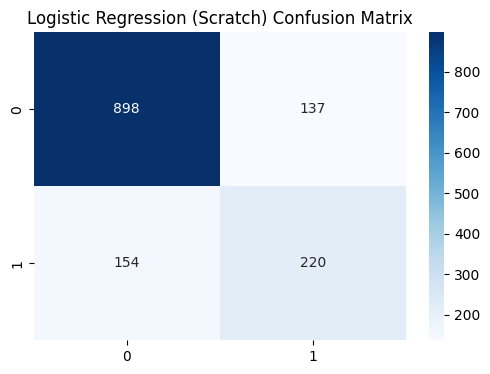

In [20]:
# Train and evaluate Logistic Regression from scratch
log_reg_scratch = LogisticRegressionScratch()
log_reg_scratch.fit(X_train_scaled, y_train)
y_pred_scratch = log_reg_scratch.predict(X_test_scaled)
print("Logistic Regression from scratch accuracy:", accuracy_score(y_test, y_pred_scratch))

# Confusion Matrix
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred_scratch), annot=True, cmap='Blues', fmt='d')
plt.title("Logistic Regression (Scratch) Confusion Matrix")
plt.show()


Logistic Regression (sklearn) accuracy: 0.8069552874378992


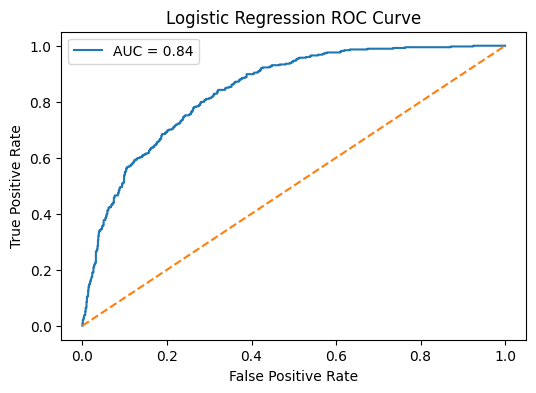

In [21]:
# Logistic Regression using sklearn
log_reg = LogisticRegression()
log_reg.fit(X_train_scaled, y_train)
y_pred_lr = log_reg.predict(X_test_scaled)
print("Logistic Regression (sklearn) accuracy:", accuracy_score(y_test, y_pred_lr))

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, log_reg.predict_proba(X_test_scaled)[:,1])
plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f'AUC = {auc(fpr, tpr):.2f}')
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Logistic Regression ROC Curve')
plt.legend()
plt.show()

In [22]:
# LDA (from scratch)
class LDA:
    def fit(self, X, y):
        self.classes = np.unique(y)
        self.means = {}
        self.priors = {}
        self.cov = np.cov(X.T)
        
        for c in self.classes:
            X_c = X[y == c]
            self.means[c] = np.mean(X_c, axis=0)
            self.priors[c] = X_c.shape[0] / X.shape[0]
    
    def predict(self, X):
        discriminants = []
        for c in self.classes:
            mean = self.means[c]
            prior = np.log(self.priors[c])
            score = np.dot(X, np.linalg.inv(self.cov)).dot(mean) - 0.5 * np.dot(mean.T, np.linalg.inv(self.cov)).dot(mean) + prior
            discriminants.append(score)
        return self.classes[np.argmax(discriminants, axis=0)]

lda_scratch = LDA()
lda_scratch.fit(X_train_scaled, y_train)
y_pred_lda_scratch = lda_scratch.predict(X_test_scaled)
print("LDA (Scratch) Accuracy:", accuracy_score(y_test, y_pred_lda_scratch))
print(classification_report(y_test, y_pred_lda_scratch))


LDA (Scratch) Accuracy: 0.5826827537260468
              precision    recall  f1-score   support

       False       0.82      0.55      0.66      1035
        True       0.35      0.67      0.46       374

    accuracy                           0.58      1409
   macro avg       0.59      0.61      0.56      1409
weighted avg       0.70      0.58      0.61      1409



In [23]:

# Linear Discriminant Analysis
lda = LinearDiscriminantAnalysis()
lda.fit(X_train_scaled, y_train)
y_pred_lda = lda.predict(X_test_scaled)
print("LDA accuracy:", accuracy_score(y_test, y_pred_lda))

LDA accuracy: 0.7856635911994322


In [24]:


# Quadratic Discriminant Analysis
qda = QuadraticDiscriminantAnalysis()
qda.fit(X_train_scaled, y_train)
y_pred_qda = qda.predict(X_test_scaled)
print("QDA accuracy:", accuracy_score(y_test, y_pred_qda))

# Naïve Bayes
nb = GaussianNB()
nb.fit(X_train_scaled, y_train)
y_pred_nb = nb.predict(X_test_scaled)
print("Naïve Bayes accuracy:", accuracy_score(y_test, y_pred_nb))


QDA accuracy: 0.7026259758694109
Naïve Bayes accuracy: 0.6557842441447835


/usr/local/lib/python3.10/dist-packages/sklearn/discriminant_analysis.py:926: UserWarning: Variables are collinear
  warnings.warn("Variables are collinear")


/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)


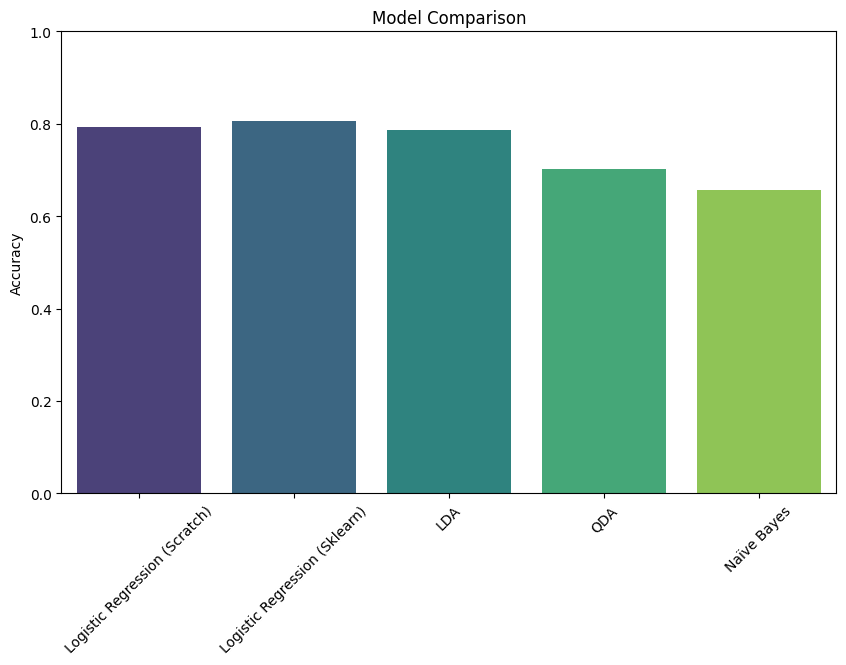

In [25]:
# Compare results
models = ['Logistic Regression (Scratch)', 'Logistic Regression (Sklearn)', 'LDA', 'QDA', 'Naïve Bayes']
accuracies = [
    accuracy_score(y_test, y_pred_scratch),
    accuracy_score(y_test, y_pred_lr),
    accuracy_score(y_test, y_pred_lda),
    accuracy_score(y_test, y_pred_qda),
    accuracy_score(y_test, y_pred_nb)
]

plt.figure(figsize=(10, 6))
sns.barplot(x=models, y=accuracies, palette='viridis')
plt.ylabel('Accuracy')
plt.title('Model Comparison')
plt.ylim(0, 1)
plt.xticks(rotation=45)
plt.show()

In [26]:
# Detailed Model Analysis
print("Classification Report - Logistic Regression:")
print(classification_report(y_test, y_pred_lr))
print("Classification Report - LDA:")
print(classification_report(y_test, y_pred_lda))
print("Classification Report - LDA from scratch:")
print(classification_report(y_test, y_pred_lda_scratch))
print("Classification Report - QDA:")
print(classification_report(y_test, y_pred_qda))
print("Classification Report - Naïve Bayes:")
print(classification_report(y_test, y_pred_nb))


Classification Report - Logistic Regression:
              precision    recall  f1-score   support

       False       0.85      0.89      0.87      1035
        True       0.66      0.57      0.61       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409

Classification Report - LDA:
              precision    recall  f1-score   support

       False       0.84      0.87      0.86      1035
        True       0.61      0.54      0.57       374

    accuracy                           0.79      1409
   macro avg       0.72      0.71      0.72      1409
weighted avg       0.78      0.79      0.78      1409

Classification Report - LDA from scratch:
              precision    recall  f1-score   support

       False       0.82      0.55      0.66      1035
        True       0.35      0.67      0.46       374

    accuracy                           0.58      1409
   macro avg